In [16]:
"""Imports"""
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
"""Constants"""
### pre measurement on 07/18
# TANK_RADIUS_1T_mm = 525.78
# BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
# BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
# BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
# TOP_PADDLE_CENTER = (86,86,766.5)

### post measurement on 07/18
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-31.75, 69.85, -1228.05)
BOTTOM_PADDLE_2_CENTER = (25.4, 177.8, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (146.05, 139.7, 766.5)

###
BPs_list = ["lol",BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER]
###

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [18]:
def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def calc_radius(x, y):
    """Simple stuff"""
    return (x**2 + y**2)**0.5

def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']


def find_Cherenkov_PMTS(entry_xy, exit_xy, pmt_positions, n=1.33, height=1994.55, angle_tolerance=0.05):
    """
    Identify PMTs inside the Cherenkov cone.

    Parameters:
    - entry_xy: tuple (x, y) of reconstructed muon entry point on top base (z = +height/2)
    - exit_xy: tuple (x, y) of reconstructed muon exit point on bottom base (z = -height/2)
    - height: cylinder height
    - pmt_positions: list of (x, y, z) tuples for all PMTs
    - n: refractive index (e.g., ~1.33 for water)
    - angle_tolerance: radians; angular deviation allowed from the Cherenkov angle

    Returns:
    - List of indices of PMTs that lie within the Cherenkov cone
    """
    # Cherenkov angle in radians
    theta_c = np.arccos(1 / n)

    # 3D entry and exit points
    entry = np.array([entry_xy[0], entry_xy[1], height / 2])
    exit = np.array([exit_xy[0], exit_xy[1], -height / 2])

    # Muon direction vector
    muon_vec = exit - entry
    muon_dir = muon_vec / np.linalg.norm(muon_vec)

    hit_pmt_indices = []

    for i, pmt in enumerate(pmt_positions):
        pmt = np.array(pmt)

        # Vector from muon entry to PMT
        r = pmt - entry

        # Project r onto muon direction
        projection_length = np.dot(r, muon_dir)
        projection_point = entry + projection_length * muon_dir

        # Perpendicular distance from PMT to muon track
        perpendicular_vec = pmt - projection_point
        perpendicular_dist = np.linalg.norm(perpendicular_vec)

        # Compute angle between r and muon direction
        angle = np.arctan2(perpendicular_dist, projection_length)

        # Only keep PMTs between entry and exit planes and within angle tolerance
        if 0 < projection_length < np.linalg.norm(muon_vec):
            if abs(angle - theta_c) <= angle_tolerance:
                hit_pmt_indices.append(i)

    return hit_pmt_indices

def get_data_for_Cher_PMTs(recos, BP_tags, pref_BP, event_idx):
    """per event"""
    num_events = len(recos)

    if BP_tags[event_idx] != pref_BP:
        return None, None, None
    if pref_BP == 1:
        BP_loc = BOTTOM_PADDLE_1_CENTER
    elif pref_BP == 2:
        BP_loc = BOTTOM_PADDLE_2_CENTER

    entry_reco_x = recos[event_idx]["reco"][0]
    entry_reco_y = recos[event_idx]["reco"][1]
    entry_true_x = TOP_PADDLE_CENTER[0]
    entry_true_y = TOP_PADDLE_CENTER[1]

    exit_reco_x = recos[event_idx]["reco"][2]
    exit_reco_y = recos[event_idx]["reco"][3]
    exit_true_x = BP_loc[0]
    exit_true_y = BP_loc[1]

    if calc_radius(entry_reco_x, entry_reco_y) > 520 or calc_radius(exit_reco_x, exit_true_y) > 520:
        return None, None, None

    top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TOP_PADDLE_CENTER[2])
    bot_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, BP_loc[2])
    
    pmt_hits = [tuple(hit[:3]) for hit in recos[event_idx]['hits']]

    return (top_intsec[0], top_intsec[1]), (bot_intsec[0], bot_intsec[1]), pmt_hits

In [19]:
user_file_choice = 4

##### water
### eloss files
elosstank_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_all/07_16_25_disk_d_phase_3_weight_1_reco_elosstank_digit_weight_all.pkl"
elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_16_25_disk_d_phase_3_cfd_1_reco_elosstank_digit_edge_all.pkl"
elosstank_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_per/07_16_25_disk_d_phase_3_weight_1_reco_elosstank_digit_weight_per.pkl"
elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_per/07_16_25_disk_d_phase_3_cfd_1_reco_elosstank_digit_edge_per.pkl"

### numCher files
numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_all/07_16_25_disk_d_phase_3_cfd_1_reco_numCher_digit_edge_all.pkl"
numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_per/07_16_25_disk_d_phase_3_cfd_1_reco_numCher_digit_edge_per.pkl"
numCher_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_all/07_16_25_disk_d_phase_3_weight_1_reco_numCher_digit_weight_all.pkl"
numCher_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_16_25_disk_d_phase_3_weight_1_reco_numCher_digit_weight_per.pkl"

water_file_list = [
    elosstank_digit_weight_all,  #0
    elosstank_digit_edge_all,    #1
    elosstank_digit_weight_per,  #2
    elosstank_digit_edge_per,    #3
    numCher_digit_edge_all,      #4
    numCher_digit_edge_per,      #5
    numCher_digit_weight_all,    #6
    numCher_digit_weight_per     #7
]
##### wbls
### only edge, weighted got messed up
wbls_elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_all.pkl"
wbls_elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_per.pkl"
wbls_numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_all.pkl"
wbls_numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_per.pkl"

wbls_file_list = [
    wbls_elosstank_digit_edge_all, #0
    wbls_elosstank_digit_edge_per, #1
    wbls_numCher_digit_edge_all,   #2
    wbls_numCher_digit_edge_per    #3
]

real_file = water_file_list[user_file_choice]
###
reco_events, BP_tags = load_data(real_file)
reco_type = real_file.split("/")[8]
# reco_type = real_file.split("/")[10]
hist_tag = str(reco_type)
print("total number of recos", len(reco_events))
print(hist_tag)
# print(reco_events[0]['total_charge']) # proof im not crazy
print(len(BP_tags))

total number of recos 5567
infile_data4
5567


In [20]:
extra = []
pmt_pos_all_events = []
for i in range(len(reco_events)):
    reco_entry, reco_exit, pmt_pos = get_data_for_Cher_PMTs(reco_events, BP_tags, 1, i)
    
    if reco_entry is None:
        pmt_pos_all_events.append([])
    else:
        pmt_pos_all_events.append(find_Cherenkov_PMTS(reco_entry, reco_exit, pmt_pos))

hit_time_fractions = []
for event_idx, group in enumerate(pmt_pos_all_events):
    if not group: continue
    pmt_hits = reco_events[event_idx]['hits']
    in_cher_median_hit_time = np.median([[pmt_hits[cher_pmt][3]] for cher_pmt in group])
    out_cher_median_hit_time = np.median([[pmt_hits[k][3]] for k in range(len(pmt_hits)) if k not in group])
    extra.append(out_cher_median_hit_time - in_cher_median_hit_time)
    
    hit_time_fractions.append(in_cher_median_hit_time/out_cher_median_hit_time)
        
        
        
print(extra)

[0.6886689196769566, -0.42942126472433984, -0.7833350157126233, 0.28845630386399534, 0.5166358397893305, -1.8430187056317777, -0.24198519745186786, 2.510608143449076, -0.14486373160747235, 1.695514375736991, -0.052296127821136906, 1.3902748718514317, 1.8105442811734065, -1.34811305309006, 0.1946017418071051, 1.0168380532098809, 0.9472826781907315, 1.2164253678063233, 0.42191993068087186, 2.678516089683626, 0.9975906148594618, 1.3218470005090808, -0.3099717127264512, 0.10897005350574318, 0.11972958238402498, 1.0593672105847531, 0.49387152548121094, -0.8084301036192301, 0.962872257091135, 1.517757636050419, 1.3534503880762827, 0.06451566486248339, -0.7873628733774467, 0.8636038971727658, 1.1379539131143588, 1.0178805461370644, 1.2838220994784706, -0.682610629594933, 1.108224858646679, 0.731349572703607, 2.0771512699280947, -0.35683526773948415, 0.03914801780001653, 0.5417027692944316, -0.2774635408245558, 0.5450523482384142, 0.17178238546853208, 2.738833075731577, 1.0089964379388903, 0.4

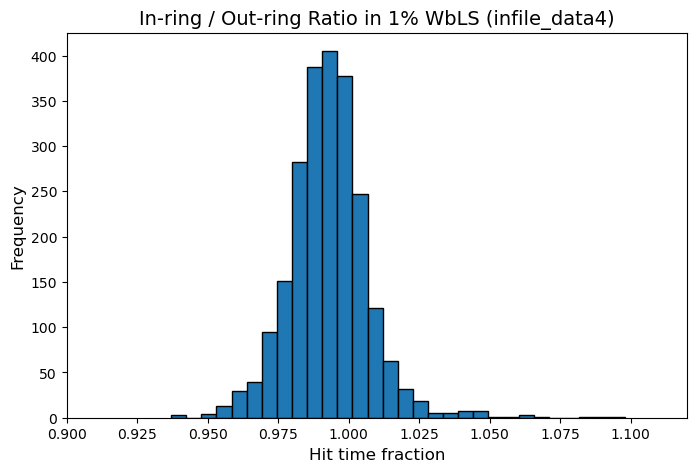

In [21]:
# Create the histogram
plt.figure(figsize=(8, 5))
plt.hist(hit_time_fractions, bins=30, edgecolor='black')

# Add labels and title
plt.xlabel('Hit time fraction', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'In-ring / Out-ring Ratio in 1% WbLS ({hist_tag})', fontsize=14)
plt.xlim(0.90, 1.12)

# Show the plot
# plt.grid(True)
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/inringoutring_wbls1pcnt_{hist_tag}.png", dpi=300, bbox_inches="tight")

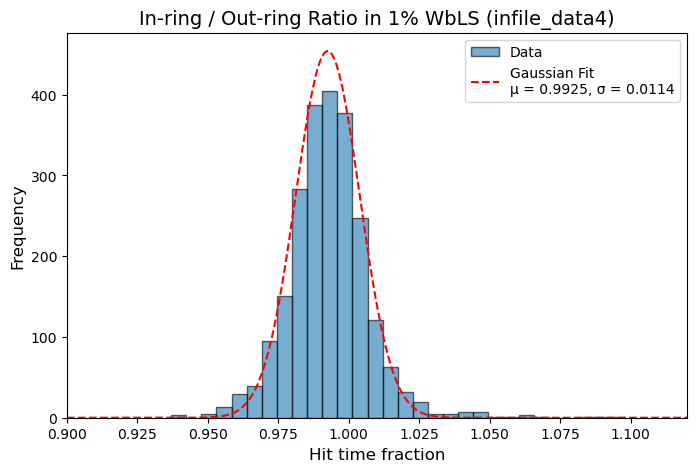

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define Gaussian function with amplitude
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(- (x - mu)**2 / (2 * sigma**2))

# Compute histogram
data = np.array(hit_time_fractions)
counts, bin_edges = np.histogram(data, bins=30, range=(0.90, 1.12))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit Gaussian to histogram
popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=[max(counts), np.mean(data), np.std(data)])
amp, mu, sigma = popt

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(data, bins=30, edgecolor='black', alpha=0.6, label='Data')

# Plot fitted Gaussian
x_fit = np.linspace(0.90, 1.12, 1000)
y_fit = gaussian(x_fit, *popt)
plt.plot(x_fit, y_fit*0.8, 'r--', label=f'Gaussian Fit\nμ = {mu:.4f}, σ = {sigma:.4f}')

# Labels and title
plt.xlabel('Hit time fraction', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'In-ring / Out-ring Ratio in 1% WbLS ({hist_tag})', fontsize=14)
plt.xlim(0.90, 1.12)
plt.legend()

plt.show()
